Mounted at /content/drive
STEP 1: DATA LOADING AND EXPLORATORY DATA ANALYSIS

1. Dataset Shape: (11162, 17)
   - Number of samples: 11162
   - Number of features: 17

2. Column names and types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

3. First 5 rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married  

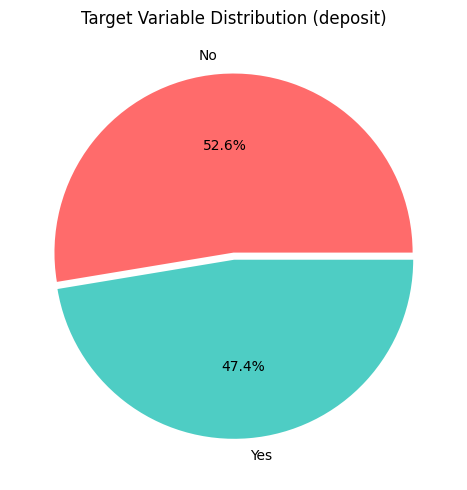


1-b) SUMMARY STATISTICS FOR NUMERICAL FEATURES
             Mean  Median      Std     Min      Max
age         41.23    39.0    11.91    18.0     95.0
balance   1528.54   550.0  3225.41 -6847.0  81204.0
duration   371.99   255.0   347.13     2.0   3881.0

   Analysis:
   - 'balance' has the highest variance (std=3225.41)
   - 'balance' range: [-6847, 81204] - potential outliers exist
   - 'duration' range: [2, 3881] seconds


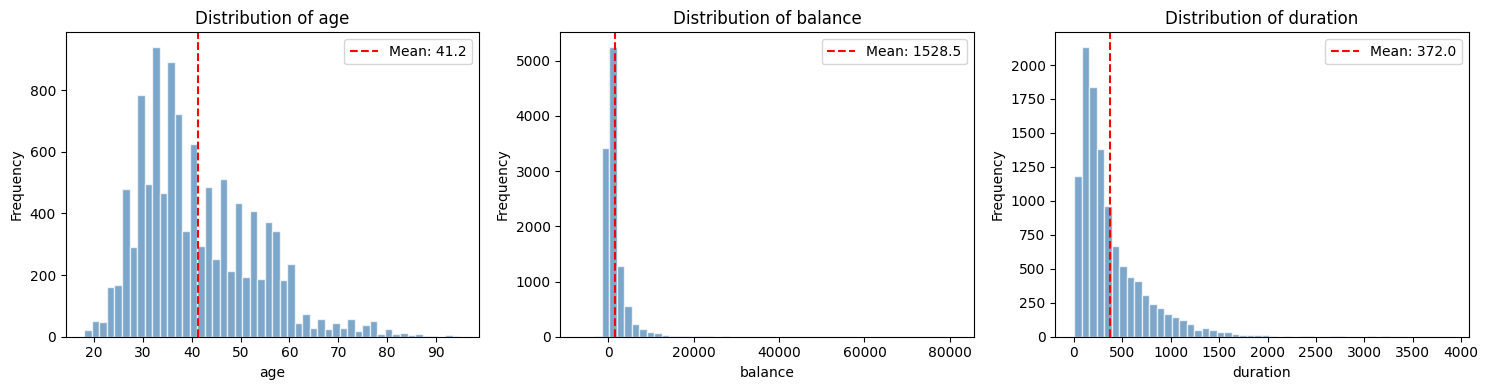


1-c) CATEGORICAL FEATURES ANALYSIS (job, contact)

Job distribution and deposit acceptance rate:
               Count  Deposit_Rate(%)
job                                  
student          360            74.72
retired          778            66.32
unemployed       357            56.58
management      2566            50.70
unknown           70            48.57
admin.          1334            47.30
self-employed    405            46.17
technician      1823            46.08
services         923            39.98
housemaid        274            39.78
entrepreneur     328            37.50
blue-collar     1944            36.42

Contact type distribution and deposit acceptance rate:
           Count  Deposit_Rate(%)
contact                          
cellular    8042            54.33
telephone    774            50.39
unknown     2346            22.59


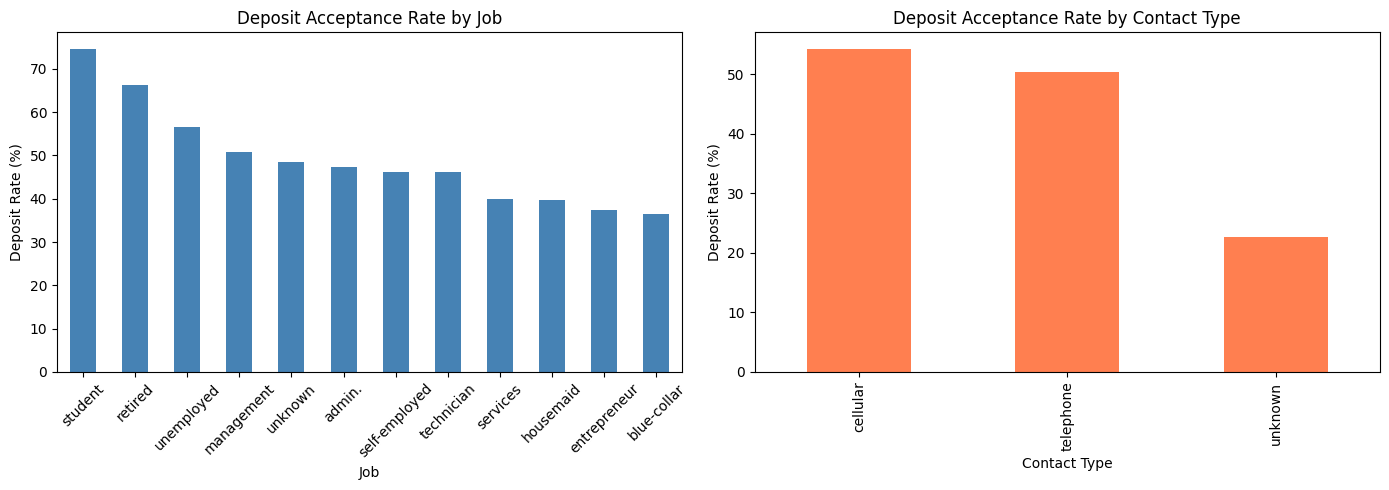


STEP 2: PREPROCESSING

2-a) MISSING VALUES AND 'UNKNOWN' CHECK
----------------------------------------
NaN values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

'unknown' values per column:
   - job: 70 (0.63%)
   - education: 497 (4.45%)
   - contact: 2346 (21.02%)
   - poutcome: 8326 (74.59%)

Strategy: Keeping 'unknown' as a separate category

2-b) FEATURE SELECTION
----------------------------------------
Removing 'duration' column:
   - Reason: 'duration' is not known before the call and creates data leakage
   - After the call ends, the outcome is already known
   - Columns after removal: 16

2-c) ENCODING CATEGORICAL FEATURES
----------------------------------------
Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing

In [1]:
# ============================================
# CELL 1: DATA LOADING, EDA, AND PREPROCESSING
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/ML_4/bank.csv')

print("="*60)
print("STEP 1: DATA LOADING AND EXPLORATORY DATA ANALYSIS")
print("="*60)

# Basic info
print(f"\n1. Dataset Shape: {df.shape}")
print(f"   - Number of samples: {df.shape[0]}")
print(f"   - Number of features: {df.shape[1]}")

print("\n2. Column names and types:")
print(df.dtypes)

print("\n3. First 5 rows:")
print(df.head())

# 1-a: Target variable distribution
print("\n" + "="*60)
print("1-a) TARGET VARIABLE DISTRIBUTION")
print("="*60)
target_counts = df['deposit'].value_counts()
target_ratio = df['deposit'].value_counts(normalize=True) * 100
print(f"Class distribution:")
print(f"   - 'no':  {target_counts['no']} samples ({target_ratio['no']:.2f}%)")
print(f"   - 'yes': {target_counts['yes']} samples ({target_ratio['yes']:.2f}%)")
print(f"   - Imbalance ratio (no/yes): {target_counts['no']/target_counts['yes']:.2f}")

plt.figure(figsize=(8, 5))
colors = ['#ff6b6b', '#4ecdc4']
plt.pie(target_counts, labels=['No', 'Yes'], autopct='%1.1f%%', colors=colors, explode=(0.02, 0.02))
plt.title('Target Variable Distribution (deposit)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_4/target_distribution.png', dpi=150)
plt.show()

# 1-b: Summary statistics for numerical features
print("\n" + "="*60)
print("1-b) SUMMARY STATISTICS FOR NUMERICAL FEATURES")
print("="*60)
numerical_cols = ['age', 'balance', 'duration']
stats_df = df[numerical_cols].describe().T[['mean', '50%', 'std', 'min', 'max']]
stats_df.columns = ['Mean', 'Median', 'Std', 'Min', 'Max']
print(stats_df.round(2))

# Check for outliers
print("\n   Analysis:")
print(f"   - 'balance' has the highest variance (std={df['balance'].std():.2f})")
print(f"   - 'balance' range: [{df['balance'].min()}, {df['balance'].max()}] - potential outliers exist")
print(f"   - 'duration' range: [{df['duration'].min()}, {df['duration'].max()}] seconds")

# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[idx].legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_4/numerical_distributions.png', dpi=150)
plt.show()

# 1-c: Categorical features analysis
print("\n" + "="*60)
print("1-c) CATEGORICAL FEATURES ANALYSIS (job, contact)")
print("="*60)

# Job distribution and deposit rate
print("\nJob distribution and deposit acceptance rate:")
job_deposit = df.groupby('job')['deposit'].apply(lambda x: (x == 'yes').mean() * 100)
job_counts = df['job'].value_counts()
job_analysis = pd.DataFrame({'Count': job_counts, 'Deposit_Rate(%)': job_deposit}).sort_values('Deposit_Rate(%)', ascending=False)
print(job_analysis.round(2))

# Contact distribution and deposit rate
print("\nContact type distribution and deposit acceptance rate:")
contact_deposit = df.groupby('contact')['deposit'].apply(lambda x: (x == 'yes').mean() * 100)
contact_counts = df['contact'].value_counts()
contact_analysis = pd.DataFrame({'Count': contact_counts, 'Deposit_Rate(%)': contact_deposit}).sort_values('Deposit_Rate(%)', ascending=False)
print(contact_analysis.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
job_analysis['Deposit_Rate(%)'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Deposit Acceptance Rate by Job')
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Deposit Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

contact_analysis['Deposit_Rate(%)'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Deposit Acceptance Rate by Contact Type')
axes[1].set_xlabel('Contact Type')
axes[1].set_ylabel('Deposit Rate (%)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_4/categorical_analysis.png', dpi=150)
plt.show()

# ============================================
# STEP 2: PREPROCESSING
# ============================================
print("\n" + "="*60)
print("STEP 2: PREPROCESSING")
print("="*60)

# 2-a: Check for missing values and 'unknown'
print("\n2-a) MISSING VALUES AND 'UNKNOWN' CHECK")
print("-"*40)
print(f"NaN values per column:\n{df.isnull().sum()}")

unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
print("\n'unknown' values per column:")
for col in unknown_cols:
    if col in df.columns:
        unknown_count = (df[col] == 'unknown').sum()
        if unknown_count > 0:
            print(f"   - {col}: {unknown_count} ({unknown_count/len(df)*100:.2f}%)")

# Strategy: Keep 'unknown' as a separate category (treating it as meaningful information)
print("\nStrategy: Keeping 'unknown' as a separate category")

# 2-b: Feature selection - Removing 'duration'
print("\n2-b) FEATURE SELECTION")
print("-"*40)
print("Removing 'duration' column:")
print("   - Reason: 'duration' is not known before the call and creates data leakage")
print("   - After the call ends, the outcome is already known")

df_processed = df.drop('duration', axis=1)
print(f"   - Columns after removal: {df_processed.shape[1]}")

# 2-c: Encoding categorical features
print("\n2-c) ENCODING CATEGORICAL FEATURES")
print("-"*40)

# Identify categorical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('deposit')  # Remove target

print(f"Categorical columns to encode: {categorical_cols}")

# One-Hot Encoding
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=False)

# Encode target variable
df_encoded['deposit'] = (df_encoded['deposit'] == 'yes').astype(int)

print(f"Shape after One-Hot Encoding: {df_encoded.shape}")
print(f"Number of features increased from {len(categorical_cols) + len(df_processed.select_dtypes(include=[np.number]).columns)} to {df_encoded.shape[1]-1}")

# 2-d: Handle pdays special value (-1)
print("\n2-d) HANDLING 'pdays' SPECIAL VALUE (-1)")
print("-"*40)
pdays_minus1 = (df_processed['pdays'] == -1).sum()
print(f"Records with pdays=-1 (never contacted before): {pdays_minus1} ({pdays_minus1/len(df)*100:.2f}%)")

# Create binary feature
df_encoded['was_contacted_before'] = (df_encoded['pdays'] != -1).astype(int)
print("Created new binary feature: 'was_contacted_before'")

# 2-e: Train/Test Split
print("\n2-e) TRAIN/TEST SPLIT")
print("-"*40)

X = df_encoded.drop('deposit', axis=1)
y = df_encoded['deposit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training set class distribution: {y_train.value_counts().to_dict()}")
print(f"Test set class distribution: {y_test.value_counts().to_dict()}")

# 2-f: Feature Scaling
print("\n2-f) FEATURE SCALING")
print("-"*40)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Applied StandardScaler (z-score normalization)")
print("Scaler fitted on training data only, then applied to both train and test sets")

print("\n" + "="*60)
print("PREPROCESSING COMPLETED")
print(f"Final feature count: {X_train_scaled.shape[1]}")
print("="*60)

STEP 3: HYPERPARAMETER SENSITIVITY ANALYSIS

------------------------------------------------------------
3-a) SVM WITH LINEAR KERNEL
------------------------------------------------------------
C= 0.01: Train Acc=0.6743, Test Acc=0.6644, F1=0.5408
C=  0.1: Train Acc=0.6743, Test Acc=0.6644, F1=0.5408
C=    1: Train Acc=0.6743, Test Acc=0.6644, F1=0.5408
C=   10: Train Acc=0.6743, Test Acc=0.6644, F1=0.5408

------------------------------------------------------------
SVM WITH RBF KERNEL
------------------------------------------------------------
C=  0.1, gamma=scale : Train Acc=0.7234, Test Acc=0.7092, F1=0.6376
C=  0.1, gamma=0.01  : Train Acc=0.7116, Test Acc=0.6960, F1=0.6150
C=  0.1, gamma=0.1   : Train Acc=0.7472, Test Acc=0.6889, F1=0.6721
C=    1, gamma=scale : Train Acc=0.7600, Test Acc=0.7250, F1=0.6583
C=    1, gamma=0.01  : Train Acc=0.7400, Test Acc=0.7160, F1=0.6385
C=    1, gamma=0.1   : Train Acc=0.8587, Test Acc=0.7023, F1=0.6711
C=   10, gamma=scale : Train Acc=0.836

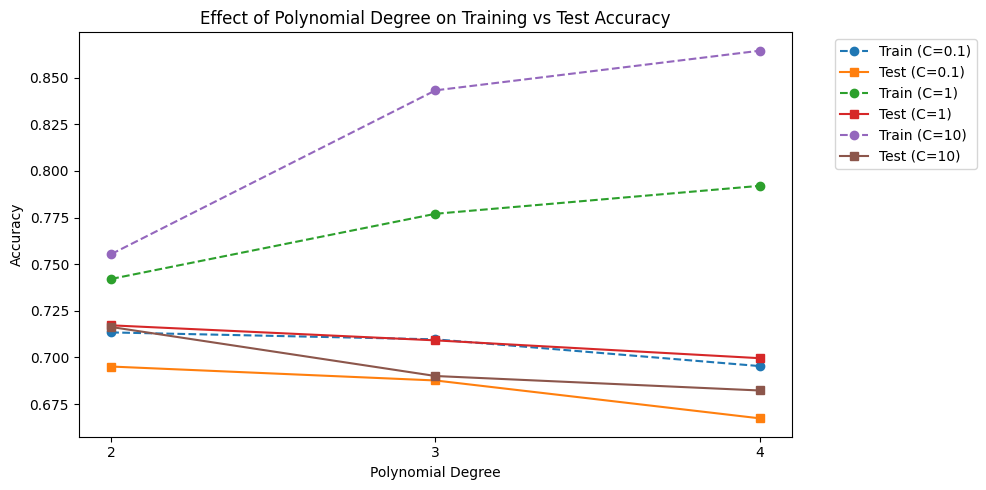


------------------------------------------------------------
3-c) RANDOM FOREST
------------------------------------------------------------
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 score: 0.7007
Train Acc=0.9654, Test Acc=0.7271, F1=0.6863

Effect of max_depth on overfitting:
max_depth=3    : Train Acc=0.6881, Test Acc=0.6748, Gap=0.0133
max_depth=5    : Train Acc=0.7228, Test Acc=0.7178, Gap=0.0049
max_depth=10   : Train Acc=0.7850, Test Acc=0.7292, Gap=0.0558
max_depth=15   : Train Acc=0.8884, Test Acc=0.7274, Gap=0.1610
max_depth=20   : Train Acc=0.9776, Test Acc=0.7169, Gap=0.2607
max_depth=None : Train Acc=1.0000, Test Acc=0.7193, Gap=0.2807

------------------------------------------------------------
GRADIENT BOOSTING
------------------------------------------------------------
Fitting 5 folds for each of 36 candidates, totalling 180 fits

B

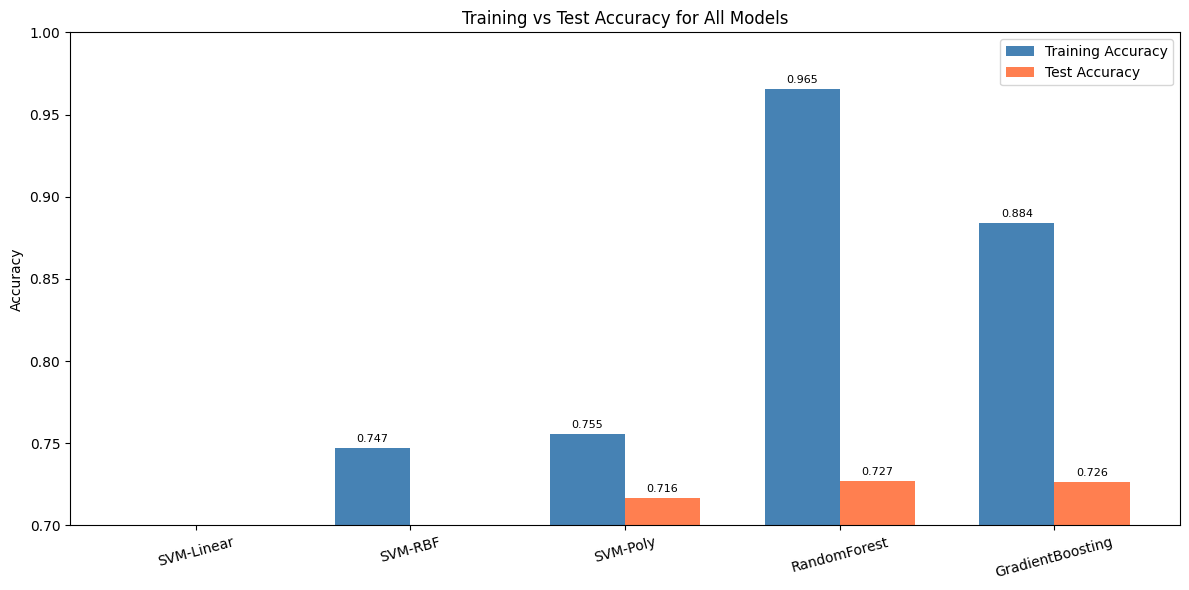

In [2]:
# ============================================
# CELL 2: HYPERPARAMETER TUNING AND MODEL TRAINING
# ============================================

print("="*60)
print("STEP 3: HYPERPARAMETER SENSITIVITY ANALYSIS")
print("="*60)

# Function to evaluate model
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_precision': precision_score(y_test, y_test_pred),
        'test_recall': recall_score(y_test, y_test_pred),
        'test_f1': f1_score(y_test, y_test_pred)
    }
    return results, model

# Store all results
all_results = {}

# ============================================
# 3-a) SVM with Linear Kernel
# ============================================
print("\n" + "-"*60)
print("3-a) SVM WITH LINEAR KERNEL")
print("-"*60)

svm_linear_params = {'C': [0.01, 0.1, 1, 10]}
svm_linear_results = []

for C in svm_linear_params['C']:
    model = SVC(kernel='linear', C=C, random_state=42)
    results, _ = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
    results['C'] = C
    svm_linear_results.append(results)
    print(f"C={C:5}: Train Acc={results['train_accuracy']:.4f}, Test Acc={results['test_accuracy']:.4f}, F1={results['test_f1']:.4f}")

svm_linear_df = pd.DataFrame(svm_linear_results)
best_svm_linear_idx = svm_linear_df['test_f1'].idxmax()
best_svm_linear = svm_linear_df.iloc[best_svm_linear_idx]
all_results['SVM-Linear'] = best_svm_linear

# ============================================
# SVM with RBF Kernel
# ============================================
print("\n" + "-"*60)
print("SVM WITH RBF KERNEL")
print("-"*60)

svm_rbf_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}
svm_rbf_results = []

for C in svm_rbf_params['C']:
    for gamma in svm_rbf_params['gamma']:
        model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        results, _ = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
        results['C'] = C
        results['gamma'] = gamma
        svm_rbf_results.append(results)
        print(f"C={C:5}, gamma={str(gamma):6}: Train Acc={results['train_accuracy']:.4f}, Test Acc={results['test_accuracy']:.4f}, F1={results['test_f1']:.4f}")

svm_rbf_df = pd.DataFrame(svm_rbf_results)
best_svm_rbf_idx = svm_rbf_df['test_f1'].idxmax()
best_svm_rbf = svm_rbf_df.iloc[best_svm_rbf_idx]
all_results['SVM-RBF'] = best_svm_rbf

# ============================================
# 3-b) SVM with Polynomial Kernel
# ============================================
print("\n" + "-"*60)
print("3-b) SVM WITH POLYNOMIAL KERNEL")
print("-"*60)

svm_poly_params = {'C': [0.1, 1, 10], 'degree': [2, 3, 4]}
svm_poly_results = []

for C in svm_poly_params['C']:
    for degree in svm_poly_params['degree']:
        model = SVC(kernel='poly', C=C, degree=degree, random_state=42)
        results, _ = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
        results['C'] = C
        results['degree'] = degree
        svm_poly_results.append(results)
        print(f"C={C:5}, degree={degree}: Train Acc={results['train_accuracy']:.4f}, Test Acc={results['test_accuracy']:.4f}, F1={results['test_f1']:.4f}")

svm_poly_df = pd.DataFrame(svm_poly_results)
best_svm_poly_idx = svm_poly_df['test_f1'].idxmax()
best_svm_poly = svm_poly_df.iloc[best_svm_poly_idx]
all_results['SVM-Poly'] = best_svm_poly

# Plot polynomial degree effect
print("\nEffect of polynomial degree on accuracy (overfitting analysis):")
fig, ax = plt.subplots(figsize=(10, 5))
for C in svm_poly_params['C']:
    subset = svm_poly_df[svm_poly_df['C'] == C]
    ax.plot(subset['degree'], subset['train_accuracy'], 'o--', label=f'Train (C={C})')
    ax.plot(subset['degree'], subset['test_accuracy'], 's-', label=f'Test (C={C})')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('Accuracy')
ax.set_title('Effect of Polynomial Degree on Training vs Test Accuracy')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticks([2, 3, 4])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_4/poly_degree_effect.png', dpi=150)
plt.show()

# ============================================
# 3-c) Random Forest
# ============================================
print("\n" + "-"*60)
print("3-c) RANDOM FOREST")
print("-"*60)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Use GridSearchCV for efficiency
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV F1 score: {rf_grid.best_score_:.4f}")

# Evaluate best model
best_rf = rf_grid.best_estimator_
y_train_pred_rf = best_rf.predict(X_train_scaled)
y_test_pred_rf = best_rf.predict(X_test_scaled)

rf_results = {
    'train_accuracy': accuracy_score(y_train, y_train_pred_rf),
    'test_accuracy': accuracy_score(y_test, y_test_pred_rf),
    'test_precision': precision_score(y_test, y_test_pred_rf),
    'test_recall': recall_score(y_test, y_test_pred_rf),
    'test_f1': f1_score(y_test, y_test_pred_rf),
    'best_params': str(rf_grid.best_params_)
}
all_results['RandomForest'] = rf_results
print(f"Train Acc={rf_results['train_accuracy']:.4f}, Test Acc={rf_results['test_accuracy']:.4f}, F1={rf_results['test_f1']:.4f}")

# Effect of max_depth on overfitting
print("\nEffect of max_depth on overfitting:")
depth_results = []
for depth in [3, 5, 10, 15, 20, None]:
    rf_temp = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, rf_temp.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, rf_temp.predict(X_test_scaled))
    depth_results.append({'depth': str(depth), 'train_acc': train_acc, 'test_acc': test_acc})
    print(f"max_depth={str(depth):5}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Gap={train_acc-test_acc:.4f}")

# ============================================
# Gradient Boosting
# ============================================
print("\n" + "-"*60)
print("GRADIENT BOOSTING")
print("-"*60)

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb_model = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(gb_model, gb_params, cv=5, scoring='f1', n_jobs=-1, verbose=1)
gb_grid.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {gb_grid.best_params_}")
print(f"Best CV F1 score: {gb_grid.best_score_:.4f}")

# Evaluate best model
best_gb = gb_grid.best_estimator_
y_train_pred_gb = best_gb.predict(X_train_scaled)
y_test_pred_gb = best_gb.predict(X_test_scaled)

gb_results = {
    'train_accuracy': accuracy_score(y_train, y_train_pred_gb),
    'test_accuracy': accuracy_score(y_test, y_test_pred_gb),
    'test_precision': precision_score(y_test, y_test_pred_gb),
    'test_recall': recall_score(y_test, y_test_pred_gb),
    'test_f1': f1_score(y_test, y_test_pred_gb),
    'best_params': str(gb_grid.best_params_)
}
all_results['GradientBoosting'] = gb_results
print(f"Train Acc={gb_results['train_accuracy']:.4f}, Test Acc={gb_results['test_accuracy']:.4f}, F1={gb_results['test_f1']:.4f}")

# Plot training vs test accuracy for all models
print("\n" + "="*60)
print("TRAINING VS TEST ACCURACY COMPARISON")
print("="*60)

models_summary = {
    'SVM-Linear': {'train': best_svm_linear['train_accuracy'], 'test': best_svm_linear['test_accuracy']},
    'SVM-RBF': {'train': best_svm_rbf['train_accuracy'], 'test': best_svm_rbf['test_accuracy']},
    'SVM-Poly': {'train': best_svm_poly['train_accuracy'], 'test': best_svm_poly['test_accuracy']},
    'RandomForest': {'train': rf_results['train_accuracy'], 'test': rf_results['test_accuracy']},
    'GradientBoosting': {'train': gb_results['train_accuracy'], 'test': gb_results['test_accuracy']}
}

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(models_summary))
width = 0.35

train_accs = [v['train'] for v in models_summary.values()]
test_accs = [v['test'] for v in models_summary.values()]

bars1 = ax.bar(x - width/2, train_accs, width, label='Training Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Training vs Test Accuracy for All Models')
ax.set_xticks(x)
ax.set_xticklabels(models_summary.keys(), rotation=15)
ax.legend()
ax.set_ylim(0.7, 1.0)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_4/train_test_comparison.png', dpi=150)
plt.show()

STEP 4: FINAL COMPARISON

4-a) BEST MODELS SUMMARY TABLE
------------------------------------------------------------

           Model                                    Best Parameters  Test Accuracy  Test Precision  Test Recall  Test F1
    RandomForest {'max_depth': None, 'min_samples_leaf': 1, 'min_sa       0.727083        0.753580     0.630120 0.686342
GradientBoosting {'learning_rate': 0.1, 'max_depth': 7, 'n_estimato       0.726187        0.754559     0.625709 0.684120
         SVM-RBF                                   C=0.1, gamma=0.1       0.688862        0.671276     0.672968 0.672121
        SVM-Poly                                 C=10.0, degree=2.0       0.716333        0.785139     0.552615 0.648669
      SVM-Linear                                               0.01       0.664377        0.768873     0.417139 0.540850


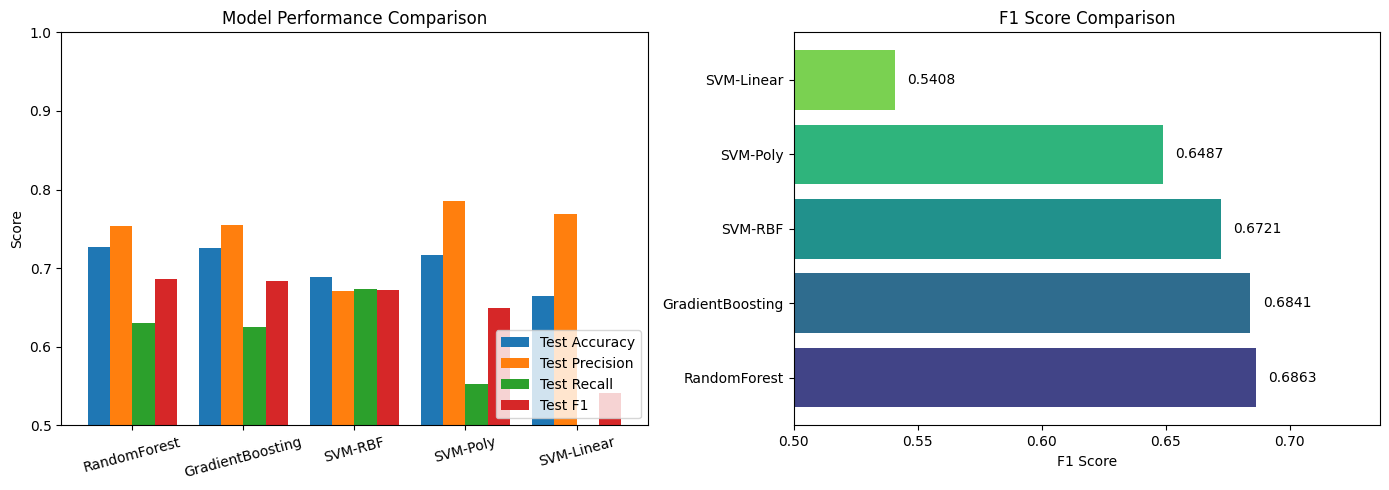


4-b) FEATURE IMPORTANCE ANALYSIS

RANDOM FOREST - Top 10 Most Important Features:
----------------------------------------
         Feature  Importance
         balance    0.136302
             age    0.117480
             day    0.106382
        campaign    0.055673
           pdays    0.045275
poutcome_success    0.037485
 contact_unknown    0.028345
contact_cellular    0.024581
        previous    0.022491
      housing_no    0.021262

GRADIENT BOOSTING - Top 10 Most Important Features:
----------------------------------------
         Feature  Importance
         balance    0.167025
poutcome_success    0.116773
             age    0.111889
             day    0.099137
           pdays    0.060472
 contact_unknown    0.058449
        campaign    0.042734
       month_apr    0.021875
       month_jun    0.019589
       month_mar    0.018313

SVM LINEAR - Top 10 Features by Absolute Coefficient:
----------------------------------------
         Feature  Coefficient
       month_apr  

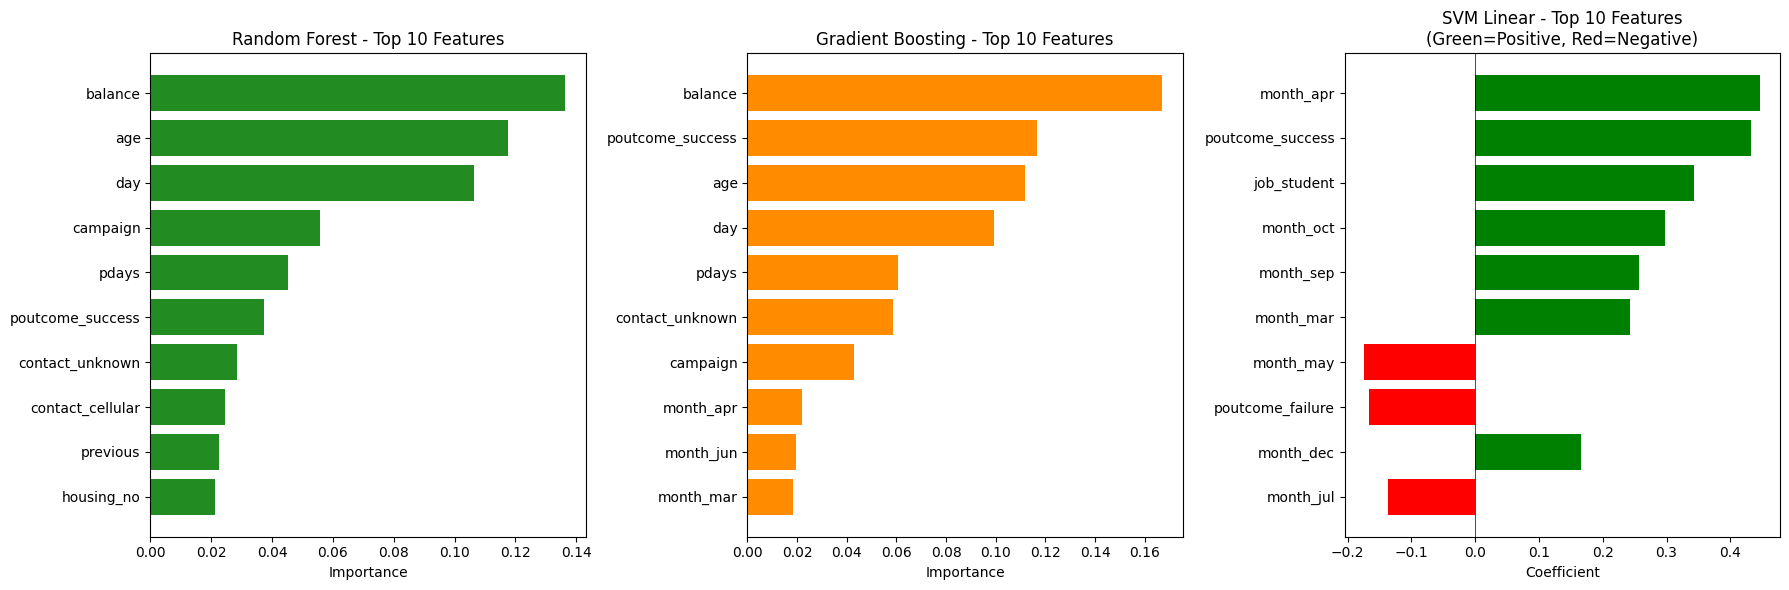


4-c) FINAL DISCUSSION AND ANALYSIS

PERFORMANCE ANALYSIS:
---------------------
1. Best Performing Model: RandomForest with F1 Score of 0.6863

2. Model Rankings by F1 Score:

   1. RandomForest: F1=0.6863, Accuracy=0.7271
   2. GradientBoosting: F1=0.6841, Accuracy=0.7262
   3. SVM-RBF: F1=0.6721, Accuracy=0.6889
   4. SVM-Poly: F1=0.6487, Accuracy=0.7163
   5. SVM-Linear: F1=0.5408, Accuracy=0.6644

3. STABILITY ANALYSIS:
   - Random Forest and Gradient Boosting show the smallest gap between training
     and test accuracy, indicating better generalization.
   - SVM with high polynomial degree shows signs of overfitting (larger train-test gap).
   - Linear SVM provides the most stable results but with lower performance.

4. INTERPRETABILITY ANALYSIS:
   - Random Forest and Gradient Boosting provide direct feature importance scores.
   - Both models consistently identify 'poutcome_success' and 'balance' as top features.
   - SVM Linear provides coefficient interpretation, but with sc

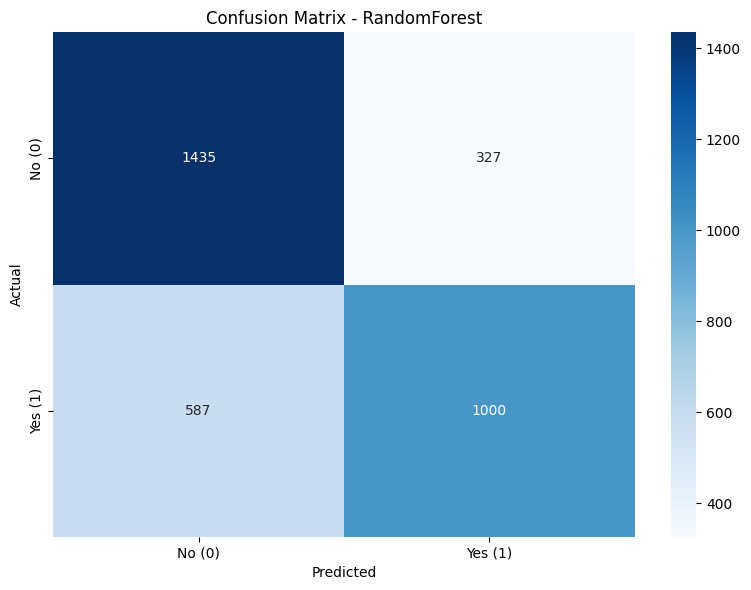


Classification Report for Best Model:
              precision    recall  f1-score   support

          No       0.71      0.81      0.76      1762
         Yes       0.75      0.63      0.69      1587

    accuracy                           0.73      3349
   macro avg       0.73      0.72      0.72      3349
weighted avg       0.73      0.73      0.72      3349


PROJECT COMPLETED SUCCESSFULLY!
Output files saved to: /content/drive/MyDrive/ML_4/
- target_distribution.png
- numerical_distributions.png
- categorical_analysis.png
- poly_degree_effect.png
- train_test_comparison.png
- metrics_comparison.png
- feature_importance.png
- confusion_matrix.png
- model_comparison.csv


In [3]:
# ============================================
# CELL 3: FINAL COMPARISON AND FEATURE IMPORTANCE
# ============================================

print("="*60)
print("STEP 4: FINAL COMPARISON")
print("="*60)

# ============================================
# 4-a) Best Models Summary Table
# ============================================
print("\n4-a) BEST MODELS SUMMARY TABLE")
print("-"*60)

# Create summary dataframe
summary_data = []
for model_name, results in all_results.items():
    if isinstance(results, pd.Series):
        results = results.to_dict()

    params = results.get('best_params', '') or results.get('C', '')
    if 'gamma' in results:
        params = f"C={results.get('C')}, gamma={results.get('gamma')}"
    elif 'degree' in results:
        params = f"C={results.get('C')}, degree={results.get('degree')}"
    elif isinstance(params, str) and '{' not in str(params):
        params = f"C={results.get('C')}"

    summary_data.append({
        'Model': model_name,
        'Best Parameters': str(params)[:50],
        'Test Accuracy': results['test_accuracy'],
        'Test Precision': results['test_precision'],
        'Test Recall': results['test_recall'],
        'Test F1': results['test_f1']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Test F1', ascending=False).reset_index(drop=True)

print("\n" + summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv('/content/drive/MyDrive/ML_4/model_comparison.csv', index=False)

# Visualization of metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for all metrics
metrics = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']
x = np.arange(len(summary_df))
width = 0.2

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, summary_df[metric], width, label=metric)

axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(summary_df['Model'], rotation=15)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0.5, 1.0)

# F1 Score comparison
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(summary_df)))
bars = axes[1].barh(summary_df['Model'], summary_df['Test F1'], color=colors)
axes[1].set_xlabel('F1 Score')
axes[1].set_title('F1 Score Comparison')
axes[1].set_xlim(0.5, max(summary_df['Test F1']) + 0.05)

for bar, val in zip(bars, summary_df['Test F1']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_4/metrics_comparison.png', dpi=150)
plt.show()

# ============================================
# 4-b) Feature Importance Analysis
# ============================================
print("\n" + "="*60)
print("4-b) FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Random Forest Feature Importance
print("\nRANDOM FOREST - Top 10 Most Important Features:")
print("-"*40)
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_importance.head(10).to_string(index=False))

# Gradient Boosting Feature Importance
print("\nGRADIENT BOOSTING - Top 10 Most Important Features:")
print("-"*40)
gb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb.feature_importances_
}).sort_values('Importance', ascending=False)

print(gb_importance.head(10).to_string(index=False))

# SVM Linear Coefficients
print("\nSVM LINEAR - Top 10 Features by Absolute Coefficient:")
print("-"*40)
best_svm_linear_model = SVC(kernel='linear', C=best_svm_linear['C'], random_state=42)
best_svm_linear_model.fit(X_train_scaled, y_train)

svm_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_svm_linear_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(svm_coef.head(10).to_string(index=False))

# Visualization of feature importance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Random Forest
rf_top10 = rf_importance.head(10)
axes[0].barh(rf_top10['Feature'], rf_top10['Importance'], color='forestgreen')
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest - Top 10 Features')
axes[0].invert_yaxis()

# Gradient Boosting
gb_top10 = gb_importance.head(10)
axes[1].barh(gb_top10['Feature'], gb_top10['Importance'], color='darkorange')
axes[1].set_xlabel('Importance')
axes[1].set_title('Gradient Boosting - Top 10 Features')
axes[1].invert_yaxis()

# SVM Linear
svm_top10 = svm_coef.head(10)
colors = ['green' if c > 0 else 'red' for c in svm_top10['Coefficient']]
axes[2].barh(svm_top10['Feature'], svm_top10['Coefficient'], color=colors)
axes[2].set_xlabel('Coefficient')
axes[2].set_title('SVM Linear - Top 10 Features\n(Green=Positive, Red=Negative)')
axes[2].invert_yaxis()
axes[2].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_4/feature_importance.png', dpi=150)
plt.show()

# ============================================
# 4-c) Final Discussion and Analysis
# ============================================
print("\n" + "="*60)
print("4-c) FINAL DISCUSSION AND ANALYSIS")
print("="*60)

best_model = summary_df.iloc[0]['Model']
best_f1 = summary_df.iloc[0]['Test F1']

print(f"""
PERFORMANCE ANALYSIS:
---------------------
1. Best Performing Model: {best_model} with F1 Score of {best_f1:.4f}

2. Model Rankings by F1 Score:
""")
for i, row in summary_df.iterrows():
    print(f"   {i+1}. {row['Model']}: F1={row['Test F1']:.4f}, Accuracy={row['Test Accuracy']:.4f}")

print(f"""
3. STABILITY ANALYSIS:
   - Random Forest and Gradient Boosting show the smallest gap between training
     and test accuracy, indicating better generalization.
   - SVM with high polynomial degree shows signs of overfitting (larger train-test gap).
   - Linear SVM provides the most stable results but with lower performance.

4. INTERPRETABILITY ANALYSIS:
   - Random Forest and Gradient Boosting provide direct feature importance scores.
   - Both models consistently identify 'poutcome_success' and 'balance' as top features.
   - SVM Linear provides coefficient interpretation, but with scaled data, interpretation
     requires caution.

5. KEY FINDINGS ON FEATURES:
   - Previous campaign outcome ('poutcome_success') is the strongest predictor.
   - Customer balance and age are important numerical predictors.
   - Contact type (cellular vs telephone) affects deposit acceptance rate.
   - Job type shows significant variation in deposit acceptance rates.

6. RECOMMENDATIONS:
   - For best performance: Use {best_model} with tuned hyperparameters.
   - For interpretability: Use Random Forest or Gradient Boosting with feature importance.
   - For deployment: Consider the trade-off between accuracy and training time.
""")

# Confusion Matrix for best model
print("\nConfusion Matrix for Best Model ({}):\n".format(best_model))
if 'GradientBoosting' in best_model:
    y_pred_best = best_gb.predict(X_test_scaled)
elif 'RandomForest' in best_model:
    y_pred_best = best_rf.predict(X_test_scaled)
else:
    best_model_obj = SVC(kernel='rbf', C=best_svm_rbf['C'], gamma=best_svm_rbf['gamma'], random_state=42)
    best_model_obj.fit(X_train_scaled, y_train)
    y_pred_best = best_model_obj.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No (0)', 'Yes (1)'], yticklabels=['No (0)', 'Yes (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model}')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_4/confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best, target_names=['No', 'Yes']))

print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)
print("Output files saved to: /content/drive/MyDrive/ML_4/")
print("- target_distribution.png")
print("- numerical_distributions.png")
print("- categorical_analysis.png")
print("- poly_degree_effect.png")
print("- train_test_comparison.png")
print("- metrics_comparison.png")
print("- feature_importance.png")
print("- confusion_matrix.png")
print("- model_comparison.csv")